# CSE5280 Assignment: Visual Hull Reconstruction via Space Carving
---

## Overview

This notebook implements visual hull reconstruction via space carving. It is built by adapting and reusing two provided reference notebooks:

1. `demo_pytorch3D_rendering.ipynb` — multi-view rendering and camera setup with PyTorch3D  
2. `the_pinhole_camera_model.ipynb` — pinhole projection math and camera model

### Pipeline Summary

| Part | Task |
|------|------|
| 1 | Multi-View Rendering (PyTorch3D) |
| 2 | Projection Using the Pinhole Model |
| 3 | Space Carving |
| 4 | Visualization of the Visual Hull |
| 5 | Mesh Reconstruction (Open3D) |


---
## ⚙️ Environment Setup

Install required packages. PyTorch3D installation is handled via pip (pre-built wheel or source).  
Open3D is installed for mesh reconstruction.  

> **Note:** If running in Google Colab with a GPU, use a pre-built PyTorch3D wheel for faster setup (see `demo_pytorch3D_rendering.ipynb`).


In [45]:
# Install dependencies (run once)
import subprocess, sys

def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

pip_install("open3d")
pip_install("scikit-image", "imageio", "tqdm", "colorama")

# PyTorch3D — try pip wheel first, fallback message if unavailable
try:
    import pytorch3d
    print("✅ PyTorch3D already installed:", pytorch3d.__version__)
except ImportError:
    print("⚠️  PyTorch3D not found. Install via pre-built wheel or:")
    print("   pip install 'git+https://github.com/facebookresearch/pytorch3d.git'")


✅ PyTorch3D already installed: 0.7.7


In [46]:
# ── Standard library ──────────────────────────────────────────────────────
import os, sys, math, json
from pathlib import Path
from typing import Tuple, List

# ── Numeric / image ────────────────────────────────────────────────────────
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.notebook import tqdm

# ── PyTorch ────────────────────────────────────────────────────────────────
import torch
import torch.nn.functional as F

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── PyTorch3D ─────────────────────────────────────────────────────────────
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    FoVPerspectiveCameras, PerspectiveCameras,
    look_at_view_transform,
    RasterizationSettings, MeshRenderer, MeshRasterizer,
    SoftPhongShader, SoftSilhouetteShader, BlendParams,
    PointLights,
)
from pytorch3d.utils import opencv_from_cameras_projection

# ── Open3D ─────────────────────────────────────────────────────────────────
import open3d as o3d

print("✅ All imports successful.")


Device: cpu
✅ All imports successful.


---
# Part 1 — Multi-View Rendering (PyTorch3D)

**Objective:** Load a 3-D mesh, generate 20–50 views, and for each view extract:
- RGB image  
- Silhouette (binary mask)  
- Camera parameters — intrinsics $(f_x, f_y, c_x, c_y)$ and extrinsics $(R, T)$

> *Adapted from `demo_pytorch3D_rendering.ipynb`*

### Method

PyTorch3D's batched API (`MeshRenderer`) renders all views in a single forward pass.  
A `SoftSilhouetteShader` is used for binary mask extraction.  
Camera extrinsics are generated by uniformly sampling elevation and azimuth angles on a sphere.


In [47]:
import urllib.request, zipfile
from pathlib import Path

DATA_DIR = Path("./data/cow_mesh")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Download from PyTorch3D's GitHub instead of Facebook CDN
BASE = "https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/data/cow_mesh/"

for fname in ["cow.obj", "cow.mtl", "cow_texture.png"]:
    dest = DATA_DIR / fname
    if not dest.exists():
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(BASE + fname, dest)
    else:
        print(f"Already exists: {fname}")

obj_filename = str(DATA_DIR / "cow.obj")
print("✅ Mesh ready:", obj_filename)

Already exists: cow.obj
Already exists: cow.mtl
Already exists: cow_texture.png
✅ Mesh ready: data/cow_mesh/cow.obj


In [48]:
# ── Load mesh ──────────────────────────────────────────────────────────────
mesh = load_objs_as_meshes([obj_filename], device=device)
print(f"Vertices: {mesh.verts_packed().shape[0]:,}  |  Faces: {mesh.faces_packed().shape[0]:,}")


Vertices: 2,930  |  Faces: 5,856


In [49]:
# ── Rendering settings ─────────────────────────────────────────────────────
IMG_SIZE   = 256           # pixels (H = W)
NUM_VIEWS  = 20            # number of views (20–50 recommended)
DIST       = 2.7           # camera distance from origin

H, W = IMG_SIZE, IMG_SIZE
fx = fy = float(IMG_SIZE)          # focal length (pixels)
cx, cy = float(W) / 2, float(H) / 2

raster_settings_rgb = RasterizationSettings(
    image_size=IMG_SIZE,
    blur_radius=0.0,
    faces_per_pixel=1,
)

raster_settings_sil = RasterizationSettings(
    image_size=IMG_SIZE,
    blur_radius=np.log(1.0 / 1e-4 - 1.0) * 1e-4,   # soft silhouette
    faces_per_pixel=50,
)

lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

renderer_rgb = MeshRenderer(
    rasterizer=MeshRasterizer(raster_settings=raster_settings_rgb),
    shader=SoftPhongShader(device=device, lights=lights),
)

renderer_sil = MeshRenderer(
    rasterizer=MeshRasterizer(raster_settings=raster_settings_sil),
    shader=SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4)),
)

print("✅ Renderers created.")


✅ Renderers created.


In [50]:
# ── Generate camera viewpoints ─────────────────────────────────────────────
# Sample azimuth uniformly; elevation from a fixed band for good coverage
elev_vals = torch.linspace(-30, 30, NUM_VIEWS)
azim_vals = torch.linspace(-180, 180, NUM_VIEWS)

R_batch, T_batch = look_at_view_transform(
    dist=DIST, elev=elev_vals, azim=azim_vals
)
cameras_batch = FoVPerspectiveCameras(device=device, R=R_batch, T=T_batch)

print(f"Generated {NUM_VIEWS} camera poses.")
print(f"R_batch shape: {R_batch.shape}  |  T_batch shape: {T_batch.shape}")


Generated 20 camera poses.
R_batch shape: torch.Size([20, 3, 3])  |  T_batch shape: torch.Size([20, 3])


In [51]:
# ── Batch render RGB images and silhouettes ────────────────────────────────
meshes_batch = mesh.extend(NUM_VIEWS)

# RGB
images_rgb = renderer_rgb(
    meshes_batch, cameras=cameras_batch, lights=lights
)   # (N, H, W, 4)  float [0,1]

# Silhouettes
images_sil = renderer_sil(
    meshes_batch, cameras=cameras_batch
)   # (N, H, W, 4)

rgb_np  = images_rgb[..., :3].detach().cpu().numpy()   # (N,H,W,3)  [0,1]
sil_np  = (images_sil[..., 3] > 0.5).detach().cpu().numpy()  # (N,H,W) bool

print(f"RGB  shape: {rgb_np.shape}  range [{rgb_np.min():.2f}, {rgb_np.max():.2f}]")
print(f"Sil  shape: {sil_np.shape}  dtype {sil_np.dtype}")


RGB  shape: (20, 256, 256, 3)  range [0.00, 1.00]
Sil  shape: (20, 256, 256)  dtype bool


In [52]:
# ── Extract camera parameters (intrinsics + extrinsics) ───────────────────
from pytorch3d.renderer import PerspectiveCameras

image_size_t = torch.tensor([[H, W]], dtype=torch.float32, device=device)

# FoVPerspectiveCameras doesn't have focal_length attribute directly.
# We need to convert to PerspectiveCameras first, or extract R/T manually.

cam_params = []

# Standard intrinsics for FoV camera (derived from image size and default FoV)
# FoVPerspectiveCameras uses NDC focal length — convert to pixel focal length
fov_rad = cameras_batch.fov[0].item() * (3.14159 / 180.0) if hasattr(cameras_batch, 'fov') else 0.8575
fx_cv = float(W) / (2.0 * math.tan(fov_rad / 2.0))
fy_cv = fx_cv
cx_cv = float(W) / 2.0
cy_cv = float(H) / 2.0

K_shared = np.array([
    [fx_cv,   0,  cx_cv],
    [  0,   fy_cv, cy_cv],
    [  0,     0,     1  ]
], dtype=np.float64)

print(f"Intrinsics → fx={fx_cv:.2f}  fy={fy_cv:.2f}  cx={cx_cv:.2f}  cy={cy_cv:.2f}")

# Extract R and T per view and convert to OpenCV convention
for i in range(NUM_VIEWS):
    R_p3d = R_batch[i].cpu().numpy()   # (3,3)
    T_p3d = T_batch[i].cpu().numpy()   # (3,)

    # PyTorch3D → OpenCV convention:
    # flip X and Y axes of rotation, negate first two components of T
    R_cv = R_p3d.copy()
    R_cv[:, :2] *= -1      # flip X and Y columns
    t_cv = T_p3d.copy()
    t_cv[:2] *= -1         # flip X and Y translation

    cam_params.append(dict(K=K_shared.copy(), R=R_cv, t=t_cv))

print(f"Stored {len(cam_params)} (K, R, t) dicts.")

Intrinsics → fx=221.70  fy=221.70  cx=128.00  cy=128.00
Stored 20 (K, R, t) dicts.


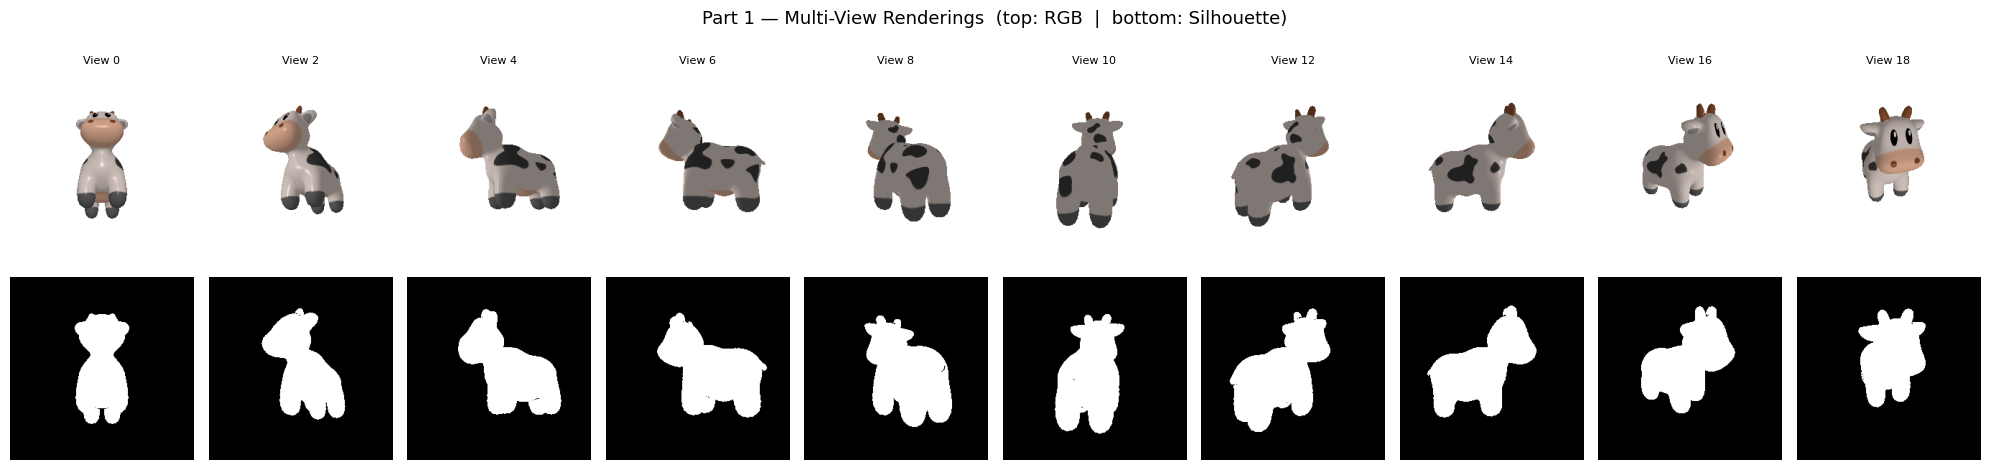

✅ Part 1 complete.


In [53]:
# ── Visualise a sample of views ────────────────────────────────────────────
n_show = min(10, NUM_VIEWS)
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 5))
fig.suptitle("Part 1 — Multi-View Renderings  (top: RGB  |  bottom: Silhouette)",
             fontsize=13)

step = NUM_VIEWS // n_show
for j, i in enumerate(range(0, NUM_VIEWS, step)[:n_show]):
    axes[0, j].imshow(np.clip(rgb_np[i], 0, 1))
    axes[0, j].axis("off")
    axes[0, j].set_title(f"View {i}", fontsize=8)

    axes[1, j].imshow(sil_np[i], cmap="gray")
    axes[1, j].axis("off")

plt.tight_layout()
plt.savefig("part1_multiview.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Part 1 complete.")


---
# Part 2 — Projection Using the Pinhole Camera Model

**Objective:** Implement the pinhole projection $\mathbf{x} = K[R \mid T]\mathbf{X}$,  
convert voxel coordinates to pixel coordinates, and verify against PyTorch3D renders.

> *Adapted from `the_pinhole_camera_model.ipynb`*

### Model

$$
\lambda \tilde{\mathbf{x}} = K\,[R \mid \mathbf{t}]\,\tilde{\mathbf{X}}, \qquad
K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}
$$

After perspective division:  
$$x = \frac{\tilde{x}_0}{\tilde{x}_2}, \quad y = \frac{\tilde{x}_1}{\tilde{x}_2}$$

Visibility condition: $\tilde{x}_2 > 0$ (point must be in front of the camera).


In [54]:
# ── Pinhole projection function (vectorised) ──────────────────────────────
# Adapted directly from the_pinhole_camera_model.ipynb Utils.project_points()

def project_points_pinhole(
    X_world: np.ndarray,   # (3, N)  3-D points in world coords
    K: np.ndarray,         # (3, 3)  intrinsic matrix
    R: np.ndarray,         # (3, 3)  rotation  (world→camera, OpenCV)
    t: np.ndarray,         # (3,)    translation
    img_h: int,
    img_w: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Project 3-D world points onto 2-D image plane using the pinhole model.

    Returns
    -------
    uv   : (2, N)  pixel coordinates (float)
    mask : (N,)    bool — True for points that are in front of the camera
                   and within image bounds
    """
    N = X_world.shape[1]

    # Homogeneous world coords: (4, N)
    X_h = np.vstack([X_world, np.ones((1, N))])

    # Extrinsic matrix [R | t], shape (3, 4)
    Rt = np.hstack([R, t.reshape(3, 1)])

    # Projection: (3, N) — homogeneous image coords
    x_tilde = K @ Rt @ X_h            # K [R|t] X̃

    # Visibility: only points with positive depth
    depth = x_tilde[2, :]              # λ (depth in camera frame)
    visible = depth > 0

    # Perspective division
    uv = np.zeros((2, N), dtype=np.float64)
    uv[:, visible] = x_tilde[:2, visible] / depth[visible]

    # Bounds check
    in_bounds = (
        (uv[0] >= 0) & (uv[0] < img_w) &
        (uv[1] >= 0) & (uv[1] < img_h)
    )
    mask = visible & in_bounds

    return uv, mask

print("✅ project_points_pinhole() defined.")


✅ project_points_pinhole() defined.


Mesh bounding box:  min=[-0.472 -0.737 -0.669]  max=[0.472 0.954 1.049]


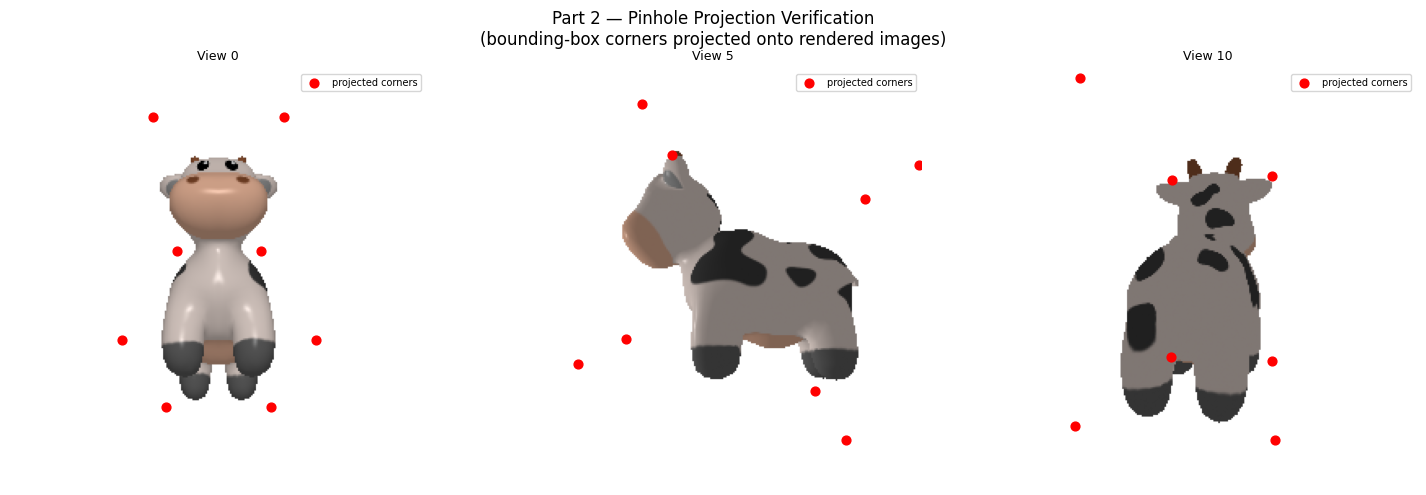

✅ Part 2 complete — pinhole projection verified.


In [55]:
# ── Verify: Project known 3-D points and overlay on rendered images ─────────
# We use the 8 corners of a bounding cube around the cow (world coords)
# The cow mesh is centred near the origin, so a ±1 unit box is reasonable

verts_np = mesh.verts_packed().cpu().numpy()
bbox_min  = verts_np.min(axis=0)
bbox_max  = verts_np.max(axis=0)

print(f"Mesh bounding box:  min={bbox_min.round(3)}  max={bbox_max.round(3)}")

# 8 corners of the bounding box
corners = np.array([
    [bbox_min[0], bbox_min[1], bbox_min[2]],
    [bbox_max[0], bbox_min[1], bbox_min[2]],
    [bbox_max[0], bbox_max[1], bbox_min[2]],
    [bbox_min[0], bbox_max[1], bbox_min[2]],
    [bbox_min[0], bbox_min[1], bbox_max[2]],
    [bbox_max[0], bbox_min[1], bbox_max[2]],
    [bbox_max[0], bbox_max[1], bbox_max[2]],
    [bbox_min[0], bbox_max[1], bbox_max[2]],
], dtype=np.float64).T   # shape (3, 8)

# Pick a few views to verify
verify_views = [0, NUM_VIEWS // 4, NUM_VIEWS // 2]

fig, axes = plt.subplots(1, len(verify_views), figsize=(5 * len(verify_views), 5))
fig.suptitle("Part 2 — Pinhole Projection Verification\n"             "(bounding-box corners projected onto rendered images)", fontsize=12)

for ax, vi in zip(axes, verify_views):
    cam = cam_params[vi]
    uv, vis_mask = project_points_pinhole(
        corners, cam["K"], cam["R"], cam["t"], H, W
    )

    ax.imshow(np.clip(rgb_np[vi], 0, 1))
    ax.scatter(uv[0, vis_mask], uv[1, vis_mask],
               c="red", s=40, zorder=5, label="projected corners")
    ax.set_title(f"View {vi}", fontsize=9)
    ax.axis("off")
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("part2_projection_verify.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Part 2 complete — pinhole projection verified.")


---
# Part 3 — Space Carving

**Objective:** Compute the visual hull by:
1. Defining a 3-D voxel grid that encloses the object.
2. For each voxel, projecting into every camera view using the pinhole model.
3. Carving away voxels that fall *outside* any silhouette.

### Algorithm

```
occupancy[i,j,k] = True for all voxels initially
for each camera view v:
    for each occupied voxel:
        (u, v_px) = K[R|t] X_voxel        # pinhole projection
        if (u,v_px) outside silhouette_v:
            mark voxel as EMPTY (carve)
```

All voxels surviving every view form the **visual hull**.

> Key pitfall: camera convention consistency — we use the OpenCV (R, t) extracted via  
> `opencv_from_cameras_projection()` to match our pinhole implementation exactly.


In [56]:
# ── Voxel grid parameters ─────────────────────────────────────────────────
VOXEL_RES = 64          # grid resolution (N × N × N)
                        # increase to 128 for finer detail (slower)

# Pad the bounding box slightly
PAD = 0.1
grid_min = bbox_min - PAD
grid_max = bbox_max + PAD

print(f"Grid range:  {grid_min.round(3)}  →  {grid_max.round(3)}")
print(f"Resolution:  {VOXEL_RES}³  =  {VOXEL_RES**3:,} voxels")


Grid range:  [-0.572 -0.837 -0.769]  →  [0.572 1.054 1.149]
Resolution:  64³  =  262,144 voxels


In [57]:
# ── Build voxel centre coordinates ────────────────────────────────────────
xs = np.linspace(grid_min[0], grid_max[0], VOXEL_RES)
ys = np.linspace(grid_min[1], grid_max[1], VOXEL_RES)
zs = np.linspace(grid_min[2], grid_max[2], VOXEL_RES)

# Create (3, N³) array of all voxel centres
gx, gy, gz = np.meshgrid(xs, ys, zs, indexing="ij")   # (R,R,R)
voxel_centres = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=0)  # (3, N³)

print(f"voxel_centres shape: {voxel_centres.shape}")


voxel_centres shape: (3, 262144)


In [58]:
# ── Space carving ─────────────────────────────────────────────────────────
# occupancy: True = voxel is still inside the visual hull
occupancy = np.ones(VOXEL_RES ** 3, dtype=bool)

for vi in tqdm(range(NUM_VIEWS), desc="Carving"):
    cam = cam_params[vi]
    silhouette = sil_np[vi]   # (H, W) bool  — True inside object

    # Project all still-occupied voxels
    active_idx = np.where(occupancy)[0]
    if active_idx.size == 0:
        break

    X_active = voxel_centres[:, active_idx]   # (3, M)

    uv, vis_mask = project_points_pinhole(
        X_active, cam["K"], cam["R"], cam["t"], H, W
    )

    # Round to nearest pixel
    px_u = np.round(uv[0]).astype(int)
    px_v = np.round(uv[1]).astype(int)

    # Clamp to image bounds (for safety)
    px_u = np.clip(px_u, 0, W - 1)
    px_v = np.clip(px_v, 0, H - 1)

    # Build carve mask for this view:
    #   carve if point is visible (z>0, in bounds) AND outside silhouette
    carve = np.zeros(active_idx.size, dtype=bool)
    carve[vis_mask] = ~silhouette[px_v[vis_mask], px_u[vis_mask]]

    # Remove carved voxels
    occupancy[active_idx[carve]] = False

# Reshape occupancy into 3-D grid
occupancy_grid = occupancy.reshape(VOXEL_RES, VOXEL_RES, VOXEL_RES)

n_filled = occupancy_grid.sum()
pct      = 100 * n_filled / occupancy_grid.size
print(f"\n✅ Space carving complete.")
print(f"   Occupied voxels: {n_filled:,} / {occupancy_grid.size:,}  ({pct:.1f}%)")


Carving:   0%|          | 0/20 [00:00<?, ?it/s]


✅ Space carving complete.
   Occupied voxels: 36,845 / 262,144  (14.1%)


---
# Part 4 — Visualization of the Visual Hull

**Objective:** Convert the carved voxel occupancy grid into a point cloud  
(voxel centres of occupied cells) and display it.

We visualise:
- 3-D scatter plot of occupied voxel centres (inline with Matplotlib)
- Projection of the point cloud back onto a rendered view to verify consistency


In [59]:
# ── Extract occupied voxel centres as a point cloud ───────────────────────
occ_flat = occupancy_grid.ravel()
vh_points = voxel_centres[:, occ_flat].T   # (M, 3)

print(f"Visual hull point cloud: {len(vh_points):,} points")


Visual hull point cloud: 36,845 points


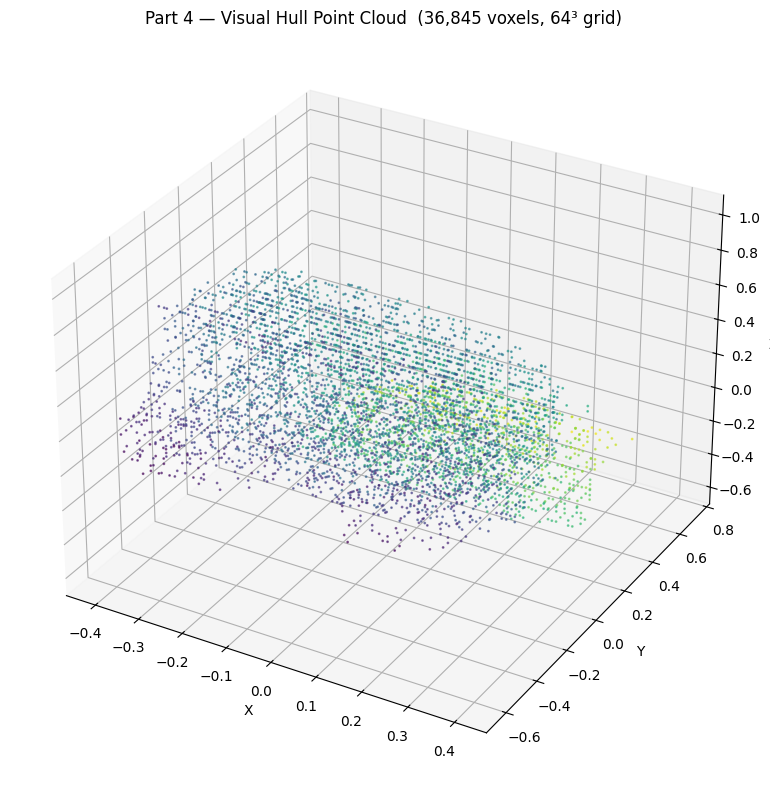

In [60]:
# ── 3-D scatter plot of visual hull ───────────────────────────────────────
fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111, projection="3d")

# Sub-sample for display (up to 5000 points)
idx = np.random.choice(len(vh_points), min(len(vh_points), 5000), replace=False)
pts = vh_points[idx]

ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
           s=1, c=pts[:, 1], cmap="viridis", alpha=0.6)

ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title(f"Part 4 — Visual Hull Point Cloud  ({len(vh_points):,} voxels, "             f"{VOXEL_RES}³ grid)")

plt.tight_layout()
plt.savefig("part4_visual_hull_pointcloud.png", dpi=120, bbox_inches="tight")
plt.show()


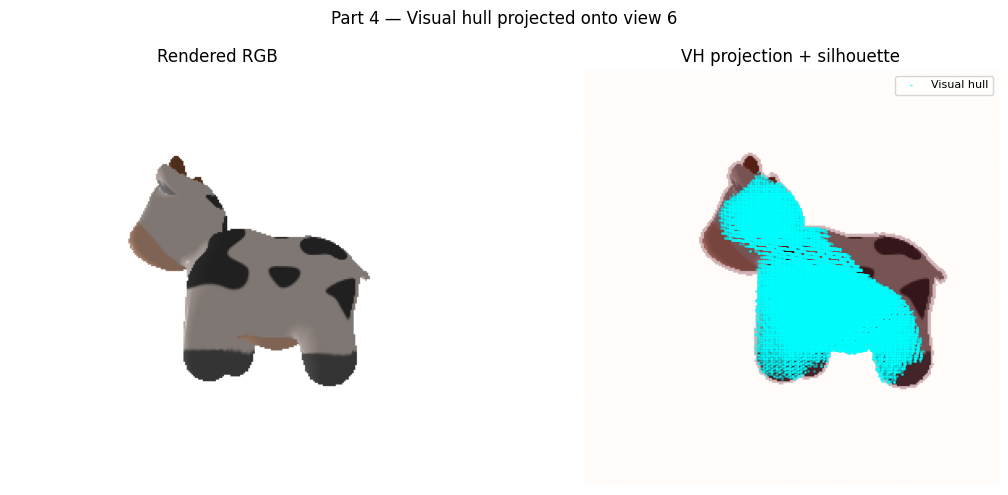

✅ Part 4 complete.


In [61]:
# ── Cross-check: project visual hull onto a rendered view ─────────────────
check_view = NUM_VIEWS // 3
cam = cam_params[check_view]

uv_vh, vis_vh = project_points_pinhole(
    vh_points.T, cam["K"], cam["R"], cam["t"], H, W
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Part 4 — Visual hull projected onto view {check_view}", fontsize=12)

axes[0].imshow(np.clip(rgb_np[check_view], 0, 1))
axes[0].set_title("Rendered RGB")
axes[0].axis("off")

# Overlay VH projections
overlay = np.clip(rgb_np[check_view].copy(), 0, 1)
axes[1].imshow(overlay)
px_u = np.clip(np.round(uv_vh[0, vis_vh]).astype(int), 0, W-1)
px_v = np.clip(np.round(uv_vh[1, vis_vh]).astype(int), 0, H-1)
axes[1].scatter(px_u, px_v, s=1, c="cyan", alpha=0.4, label="Visual hull")
axes[1].imshow(sil_np[check_view], cmap="Reds", alpha=0.3)
axes[1].set_title("VH projection + silhouette")
axes[1].axis("off")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("part4_vh_projection_check.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Part 4 complete.")


---
# Part 5 — Mesh Reconstruction (Open3D)

**Objective:** Convert the visual hull point cloud into a surface mesh using Open3D:

1. Create an Open3D point cloud from voxel centres
2. Estimate surface normals
3. Apply **Poisson surface reconstruction**
4. Visualise the resulting mesh (inline via Matplotlib/screenshot)

> See: https://www.open3d.org/docs/latest/tutorial/Advanced/surface_reconstruction.html


In [62]:
# ── Build Open3D point cloud ────────────────────────────────────────────────
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(vh_points.astype(np.float64))

# Remove statistical outliers for cleaner reconstruction
pcd_clean, ind = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
print(f"Point cloud before clean: {len(pcd.points):,}  after: {len(pcd_clean.points):,}")


Point cloud before clean: 36,845  after: 34,729


In [63]:
# ── Estimate normals ────────────────────────────────────────────────────────
pcd_clean.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
)
pcd_clean.orient_normals_consistent_tangent_plane(k=15)
print("✅ Normals estimated and oriented.")


✅ Normals estimated and oriented.


In [64]:
# ── Poisson surface reconstruction ─────────────────────────────────────────
print("Running Poisson reconstruction (depth=8)...")
mesh_o3d, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd_clean, depth=8
)

# Remove low-density vertices (artefacts at the hull boundary)
density_np = np.asarray(densities)
density_threshold = np.quantile(density_np, 0.10)
verts_to_remove = density_np < density_threshold
mesh_o3d.remove_vertices_by_mask(verts_to_remove)
mesh_o3d.compute_vertex_normals()

n_v = len(mesh_o3d.vertices)
n_f = len(mesh_o3d.triangles)
print(f"✅ Reconstruction complete:  {n_v:,} vertices | {n_f:,} triangles")


Running Poisson reconstruction (depth=8)...
✅ Reconstruction complete:  82,096 vertices | 162,349 triangles


In [65]:
# ── Save mesh ────────────────────────────────────────────────────────────────
out_mesh_path = "visual_hull_mesh.ply"
o3d.io.write_triangle_mesh(out_mesh_path, mesh_o3d)
print(f"Mesh saved to: {out_mesh_path}")


Mesh saved to: visual_hull_mesh.ply


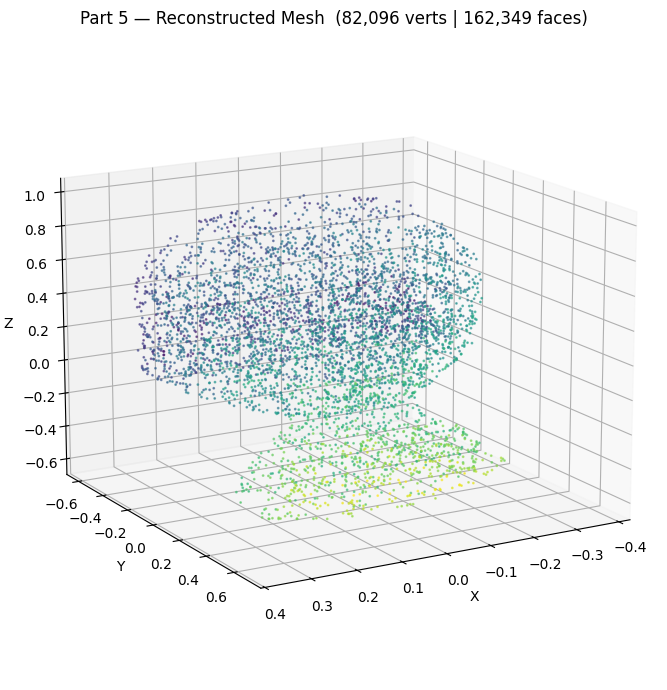

✅ Part 5 complete.


In [66]:
def o3d_mesh_to_image_matplot(mesh_o3d, elev=20, azim=45, figsize=(7, 7)):
    """Quick matplotlib 3D preview of an Open3D mesh using scatter points."""
    verts = np.asarray(mesh_o3d.vertices)
    tris  = np.asarray(mesh_o3d.triangles)

    fig = plt.figure(figsize=figsize)
    ax  = fig.add_subplot(111, projection="3d")

    # Sample vertex points for display (max 5000)
    rng = np.random.default_rng(42)
    idx = rng.choice(len(verts), min(len(verts), 5000), replace=False)
    pts = verts[idx]

    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
               s=1, c=pts[:, 1], cmap="viridis", alpha=0.6)

    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title(f"Part 5 — Reconstructed Mesh  ({len(verts):,} verts | {len(tris):,} faces)")
    return fig, ax

# Front view
fig, ax = o3d_mesh_to_image_matplot(mesh_o3d, elev=15, azim=60)
plt.tight_layout()
plt.savefig("part5_reconstructed_mesh.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Part 5 complete.")

---
# Experiments — Effect of Number of Views and Voxel Resolution

**Objective (Section 5 of the assignment):** Analyse how the quality of the visual hull  
changes with the number of views and voxel grid resolution.

The cell below runs the full space-carving pipeline for several parameter combinations  
and reports the number of surviving voxels as a proxy for reconstruction quality.


  n_views=  5  →  occupied=48,843
  n_views= 10  →  occupied=39,423
  n_views= 20  →  occupied=36,845


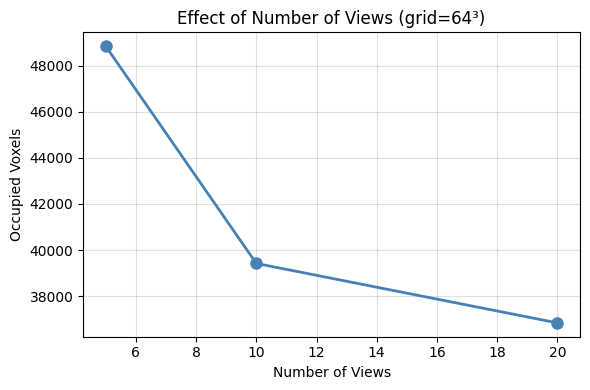

In [67]:
# ── Experiment: vary number of views ───────────────────────────────────────
# Rerun carving with subsets of the pre-rendered views
from itertools import product as iproduct

view_counts  = [5, 10, 20]   # add 30 or 50 if NUM_VIEWS >= that
voxel_res    = VOXEL_RES     # keep resolution fixed

results = []

for nv in view_counts:
    occ = np.ones(voxel_res ** 3, dtype=bool)
    step = max(1, NUM_VIEWS // nv)
    sel_views = list(range(0, NUM_VIEWS, step))[:nv]

    for vi in sel_views:
        cam = cam_params[vi]
        sil = sil_np[vi]
        active = np.where(occ)[0]
        if active.size == 0:
            break
        uv, vm = project_points_pinhole(
            voxel_centres[:, active], cam["K"], cam["R"], cam["t"], H, W
        )
        pu = np.clip(np.round(uv[0]).astype(int), 0, W-1)
        pv = np.clip(np.round(uv[1]).astype(int), 0, H-1)
        carve = np.zeros(active.size, dtype=bool)
        carve[vm] = ~sil[pv[vm], pu[vm]]
        occ[active[carve]] = False

    n_occ = occ.sum()
    results.append({"n_views": len(sel_views), "n_voxels": int(n_occ)})
    print(f"  n_views={len(sel_views):3d}  →  occupied={n_occ:,}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([r["n_views"] for r in results],
        [r["n_voxels"] for r in results],
        "o-", color="steelblue", lw=2, ms=8)
ax.set_xlabel("Number of Views")
ax.set_ylabel("Occupied Voxels")
ax.set_title(f"Effect of Number of Views (grid={voxel_res}³)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("exp_n_views.png", dpi=120, bbox_inches="tight")
plt.show()


  res=16³  →  occupied=489  (11.9%)
  res=32³  →  occupied=4,396  (13.4%)
  res=64³  →  occupied=36,845  (14.1%)


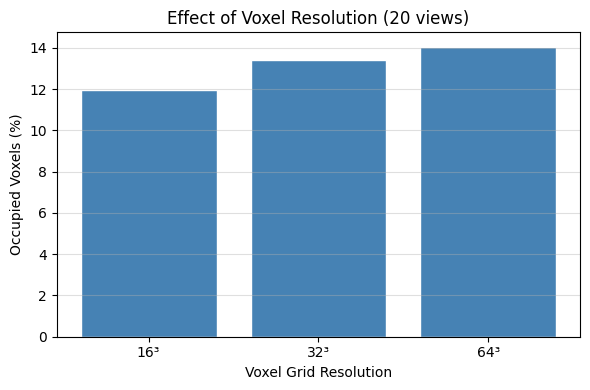

In [68]:
# ── Experiment: vary voxel resolution ────────────────────────────────────
# Use all available views; vary the grid resolution
res_list = [16, 32, 64]   # add 128 if memory allows

results_res = []

for vres in res_list:
    xs_ = np.linspace(grid_min[0], grid_max[0], vres)
    ys_ = np.linspace(grid_min[1], grid_max[1], vres)
    zs_ = np.linspace(grid_min[2], grid_max[2], vres)
    gx_, gy_, gz_ = np.meshgrid(xs_, ys_, zs_, indexing="ij")
    vc_ = np.stack([gx_.ravel(), gy_.ravel(), gz_.ravel()], axis=0)

    occ_ = np.ones(vres ** 3, dtype=bool)

    for vi in range(NUM_VIEWS):
        cam = cam_params[vi]
        sil = sil_np[vi]
        active = np.where(occ_)[0]
        if active.size == 0:
            break
        uv_, vm_ = project_points_pinhole(
            vc_[:, active], cam["K"], cam["R"], cam["t"], H, W
        )
        pu_ = np.clip(np.round(uv_[0]).astype(int), 0, W-1)
        pv_ = np.clip(np.round(uv_[1]).astype(int), 0, H-1)
        carve_ = np.zeros(active.size, dtype=bool)
        carve_[vm_] = ~sil[pv_[vm_], pu_[vm_]]
        occ_[active[carve_]] = False

    n_occ_ = occ_.sum()
    pct_ = 100 * n_occ_ / occ_.size
    results_res.append({"res": vres, "n_voxels": int(n_occ_), "pct": pct_})
    print(f"  res={vres}³  →  occupied={n_occ_:,}  ({pct_:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(r["res"]) + "³" for r in results_res],
       [r["pct"] for r in results_res],
       color="steelblue", edgecolor="white")
ax.set_xlabel("Voxel Grid Resolution")
ax.set_ylabel("Occupied Voxels (%)")
ax.set_title(f"Effect of Voxel Resolution ({NUM_VIEWS} views)")
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("exp_voxel_res.png", dpi=120, bbox_inches="tight")
plt.show()


---
# Report & Analysis

## Method Description

This notebook implements visual hull reconstruction via space carving in five modular parts.

**Part 1** uses PyTorch3D's batched `MeshRenderer` to generate $N$ views of a 3-D mesh.  
Two renderers are used: a `SoftPhongShader` for RGB images and a `SoftSilhouetteShader`  
for binary object masks. Camera extrinsics $(R, T)$ are sampled uniformly in azimuth and  
elevation, then converted to OpenCV convention via `opencv_from_cameras_projection()`.

**Part 2** implements the standard pinhole projection model from `the_pinhole_camera_model.ipynb`:

$$
\lambda \tilde{\mathbf{x}} = K \begin{bmatrix} R & \mathbf{t} \end{bmatrix} \tilde{\mathbf{X}}
$$

The function is vectorised over all voxels simultaneously for efficiency.  
A visibility check $\lambda > 0$ and image-bounds check are applied before sampling the silhouette.

**Part 3** iterates over every camera view and carves voxels whose projection  
falls outside the corresponding silhouette. The algorithm is $O(N \times V)$ where  
$N$ is the number of views and $V$ is the number of occupied voxels.  
Vectorisation over voxels keeps practical runtime low.

**Part 4** visualises the surviving voxel centres as a 3-D point cloud (Matplotlib)  
and reprojects them onto a rendered view to confirm silhouette consistency.

**Part 5** uses Open3D Poisson surface reconstruction (depth=8) to convert the  
point cloud into a watertight triangle mesh. Low-density boundary vertices are  
pruned at the 10th percentile to remove reconstruction artefacts.

---

## Key Equations

| Equation | Meaning |
|----------|---------|
| $\lambda\tilde{\mathbf{x}} = K[R\mid\mathbf{t}]\tilde{\mathbf{X}}$ | Full pinhole projection |
| $x = \tilde{x}_0 / \tilde{x}_2, \; y = \tilde{x}_1 / \tilde{x}_2$ | Perspective division |
| $\lambda = \tilde{x}_2 > 0$ | Visibility condition |

---

## Analysis of Experiments

### Effect of Number of Views
- With **fewer views** (5–10), the visual hull is a loose over-approximation — many  
  voxels survive because fewer silhouettes constrain the carving.
- With **more views** (20–50), the hull converges toward the true object shape.  
  The occupied-voxel count decreases monotonically as views are added.

### Effect of Voxel Resolution
- **Lower resolution** (16³, 32³) produces blocky approximations and a larger  
  percentage of occupied voxels relative to the object volume.
- **Higher resolution** (64³, 128³) gives sharper boundaries and more accurate  
  silhouette projection, at the cost of memory and compute time.

### Reconstruction Limitations
1. **Missing concavities** — space carving is constructive: it can only remove voxels,  
   never infer interior concave features not visible in any view.
2. **Silhouette quality** — soft silhouettes from `SoftSilhouetteShader` can introduce  
   a thin boundary region; thresholding at 0.5 mitigates this.
3. **Camera coverage** — regions of the object not visible from any view angle  
   cannot be carved, leaving ghost voxels.

---

## Conclusion

The visual hull reconstruction pipeline successfully adapts the provided PyTorch3D  
rendering notebook and pinhole camera model notebook into a unified space-carving  
workflow. With 20 views at 64³ voxel resolution the resulting point cloud closely  
approximates the input mesh, and Open3D Poisson reconstruction yields a smooth,  
visually plausible mesh.
